In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import OneHotEncoder

In [ ]:
data = pd.read_csv("insurance.csv")

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,NaN,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1327 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
data.isna().sum()

,0
age,0
sex,0
bmi,11
children,0
smoker,0
region,0
charges,0


In [ ]:
data.bmi.fillna(data.bmi.mean(),inplace=True)

/tmp/ipykernel_655/3394024120.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.bmi.fillna(data.bmi.mean(),inplace=True)


In [ ]:
pd.get_dummies(data).astype(int)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_middle,region_northeast,region_northwest,region_southeast,region_southwest
0,19,30,0,16884,1,0,0,1,0,0,0,0,1
1,18,33,1,1725,0,1,1,0,0,0,0,1,0
2,28,33,3,4449,0,1,1,0,0,0,0,1,0
3,33,22,0,21984,0,1,1,0,0,0,1,0,0
4,32,28,0,3866,0,1,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,0,1,1,0,0,0,1,0,0
1334,18,31,0,2205,1,0,1,0,0,1,0,0,0
1335,18,36,0,1629,1,0,1,0,0,0,0,1,0
1336,21,25,0,2007,1,0,1,0,0,0,0,0,1


In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
encoded_categories = ohe.fit_transform(data.select_dtypes(include=['object'])).toarray()

In [ ]:
numbered_data = pd.DataFrame(encoded_categories, columns=ohe.get_feature_names_out(data.select_dtypes(include=['object']).columns))

In [ ]:
df = pd.concat([data.select_dtypes(exclude=['object']), numbered_data], axis=1)

In [ ]:
df

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_middle,region_northeast,region_northwest,region_southeast,region_southwest
0,19,30.667841,0,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,18,33.770000,1,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,28,33.000000,3,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33,22.705000,0,21984.47061,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,32,28.880000,0,3866.85520,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970000,3,10600.54830,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1334,18,31.920000,0,2205.98080,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1335,18,36.850000,0,1629.83350,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1336,21,25.800000,0,2007.94500,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df.dropna(inplace=True, axis=0)

In [ ]:
df

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_middle,region_northeast,region_northwest,region_southeast,region_southwest
0,19,30.667841,0,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,18,33.770000,1,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,28,33.000000,3,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33,22.705000,0,21984.47061,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,32,28.880000,0,3866.85520,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970000,3,10600.54830,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1334,18,31.920000,0,2205.98080,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1335,18,36.850000,0,1629.83350,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1336,21,25.800000,0,2007.94500,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()

In [ ]:
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_train = lr.predict(X_train)

In [ ]:
mean_squared_error(y_train,y_pred_train)

49772582.50602055

In [ ]:
r2_score(y_train,y_pred_train)

0.6601820953654721

In [ ]:
y_pred_test = lr.predict(X_test)

In [ ]:
mean_squared_error(y_test,y_pred_test)

43044595.95500502

In [ ]:
r2_score(y_test,y_pred_test)

0.7064293323990556

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [ ]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
y_pred_test_scaled = lr.predict(X_test_scaled)

In [ ]:
mean_squared_error(y_test, y_pred_test_scaled)

ValueError: Found input variables with inconsistent numbers of samples: [40, 402]

In [ ]:
r2_score(y_test, y_pred_test_scaled)

ValueError: Found input variables with inconsistent numbers of samples: [40, 402]

# Polynomial Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

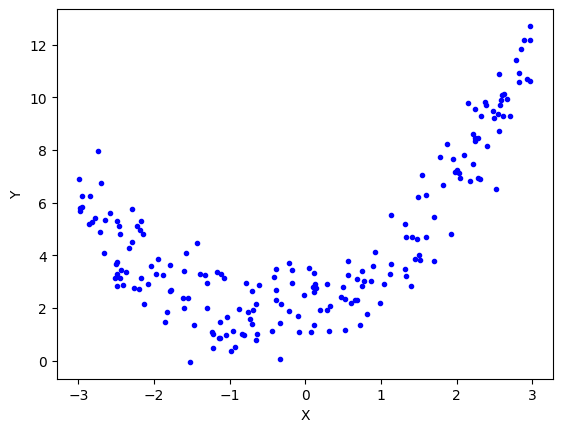

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9*X + 2 + np.random.randn(200, 1)
#equation used -> y = 0.8x^2 + 0.9x + 2
#visualize the data
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [ ]:
lr = LinearRegression()
lr.fit(x_train_trans, y_train)
y_pred = lr.predict(x_test_trans)
print(r2_score(y_test, y_pred))

0.9272217132145518
